# G1 Dataset & Tokenizers

Smoke tests for the G1 chunked HDF5 loader and two tokenizer paths:
- the in-repo single-stream tokenizer loaded from a local checkpoint, and
- the **multi-stream** tokenizer port (`MultiStreamTokenizerWrapper`) loaded
  from the upstream G1 reference checkpoint via `ckpt_format="reference"`.


## Setup

In [1]:
import torch
from hydra import initialize, compose
from omegaconf import OmegaConf
from dreamerv4uwm.models.utils import load_tokenizer

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
resolution = (256, 256)

with initialize(version_base=None, config_path="../scripts/config"):
    cfg = compose(config_name="dynamics/g1.yaml")


/home/mim-server/miniconda3/envs/dreamerv4/lib/python3.11/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'dynamics/g1.yaml': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)


In [15]:
import matplotlib.pyplot as plt
import numpy as np

def plotSnapshots(video, n_frames=5, border_width=2, figsize=None, save_path=None):
    """Plot n_frames evenly-spaced snapshots from a video tensor, separated by black borders.

    Args:
        video: (T, C, H, W) tensor with values in [0, 1].
        n_frames: number of frames to sample.
        border_width: width of black separator lines in pixels.
    """
    T = video.shape[0]
    indices = np.linspace(0, T - 1, n_frames, dtype=int)
    frames = video[indices].cpu().permute(0, 2, 3, 1).to(torch.float32).numpy()
    frames = np.clip(frames * 255, 0, 255).astype(np.uint8)
    H, W, C = frames.shape[1], frames.shape[2], frames.shape[3]
    border = np.zeros((H, border_width, C), dtype=np.uint8)
    parts = []
    for i, f in enumerate(frames):
        if i > 0:
            parts.append(border)
        parts.append(f)
    strip = np.concatenate(parts, axis=1)
    if figsize is None:
        figsize = (n_frames * 3, 3)
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.imshow(strip)
    ax.axis('off')
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=300)
    plt.show()


def plotActions(actions, figsize=None, save_path=None):
    act = actions.cpu().float().numpy() if hasattr(actions, 'cpu') else np.array(actions)
    figsize = (3, 3)
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.plot(act[:, 0], linewidth=3, label=r'$\mathbf{v_x}$')
    ax.plot(act[:, 1], linewidth=3, label=r'$\mathbf{v_y}$')
    ax.set_ylim(-1., 1.)
    ax.set_xticklabels([])
    ax.tick_params(axis='x', length=0)
    ax.tick_params(axis='y', labelsize=16)
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')
    ax.legend(fontsize=16)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=300)
    plt.show()


## G1 Dataset — load & visualize

Smoke test for `G1ChunkDataset` against the chunked HDF5 layout at
`/scratch/rk4342/datasets/G1/wm/`. Pulls one window, decodes BGR→RGB images,
and plots the 22-dim `commands` vector (3 base vel + 17 upper-body joint
targets + 2 triggers) over time.

This cell is self-contained — no tokenizer or denoiser needed.

In [3]:
import mediapy
import matplotlib.pyplot as plt
import numpy as np
from dreamerv4uwm.datasets import G1ChunkDataset

G1_DATA_PATH = "/home/mim-server/robot/GR00T-WholeBodyControl/creo-g1-teleop/new_wm_h5_segmented_small/world_model"
g1_dataset = G1ChunkDataset(
    data_dir=G1_DATA_PATH,
    window_size=64,
    stride=1,
    split="train",
    train_fraction=0.9,
    split_seed=123,
)

stats = g1_dataset.get_episode_length_statistics()
print(f"chunks={len(g1_dataset.chunk_paths)}  episodes={stats['total_episodes']}  "
      f"frames={stats['total_timesteps']:,}  windows={len(g1_dataset):,}")
print(f"episode length: min={stats['min_length']} median={stats['median_length']:.0f} "
      f"max={stats['max_length']} mean={stats['mean_length']:.1f}")

sample = g1_dataset[len(g1_dataset) // 2]
imgs_g1 = sample["image"]      # (T, 3, H, W) RGB float in [0,1]
acts_g1 = sample["action"]     # (T, 22) float32
print(f"image: shape={tuple(imgs_g1.shape)} dtype={imgs_g1.dtype} "
      f"range=[{imgs_g1.min():.3f}, {imgs_g1.max():.3f}]")
print(f"action: shape={tuple(acts_g1.shape)} dtype={acts_g1.dtype}")

G1[train]: 520576 windows from 276 episodes (of 307 total) across 228 chunks
chunks=228  episodes=307  frames=593,329  windows=520,576
episode length: min=9 median=2600 max=2700 mean=1932.7
image: shape=(64, 3, 256, 256) dtype=torch.float32 range=[0.000, 1.000]
action: shape=(64, 22) dtype=torch.float32


This browser does not support the video tag.


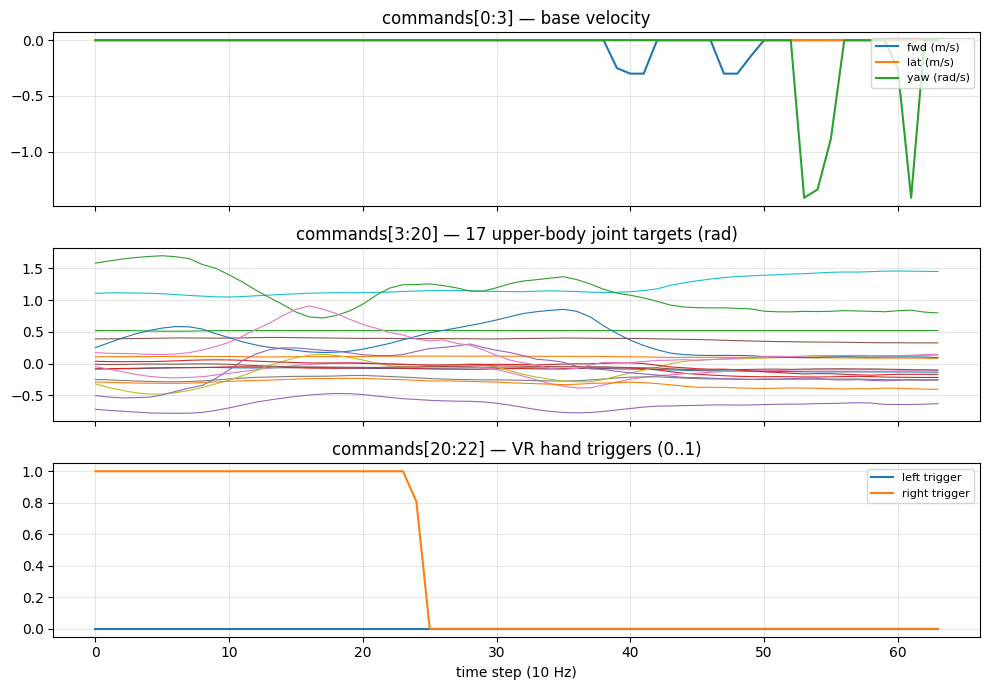

In [ ]:
# Video preview (RGB → uint8 for mediapy)
imgs_np = (imgs_g1.permute(0, 2, 3, 1).numpy() * 255).clip(0, 255).astype(np.uint8)
mediapy.show_video(imgs_np, fps=10)

# 22-dim command vector over time, grouped by semantic block
acts_np = acts_g1.numpy()
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

# Block 1: base velocity commands (fwd, lat, yaw)
for i, name in enumerate(["fwd (m/s)", "lat (m/s)", "yaw (rad/s)"]):
    axes[0].plot(acts_np[:, i], label=name, linewidth=1.5)
axes[0].set_title("commands[0:3] — base velocity")
axes[0].legend(loc="upper right", fontsize=8)
axes[0].grid(True, alpha=0.3)

# Block 2: 17 upper-body joint targets (planner permuted order)
for i in range(3, 20):
    axes[1].plot(acts_np[:, i], linewidth=0.8)
axes[1].set_title("commands[3:20] — 17 upper-body joint targets (rad)")
axes[1].grid(True, alpha=0.3)

# Block 3: hand triggers
axes[2].plot(acts_np[:, 20], label="left trigger", linewidth=1.5)
axes[2].plot(acts_np[:, 21], label="right trigger", linewidth=1.5)
axes[2].set_title("commands[20:22] — VR hand triggers (0..1)")
axes[2].set_xlabel("time step (10 Hz)")
axes[2].legend(loc="upper right", fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Single-stream tokenizer (g1_reference.pt)

In [5]:
tokenizer_ckpt="/home/mim-server/projects/rooholla/dreamerV4-UWM/checkpoints/tokenizer/g1_reference.pt"
cfg.tokenizer_ckpt=tokenizer_ckpt
tokenizer = load_tokenizer(cfg, device, max_num_forward_steps=300)
tokenizer = tokenizer.eval().cuda()

This browser does not support the video tag.


This browser does not support the video tag.


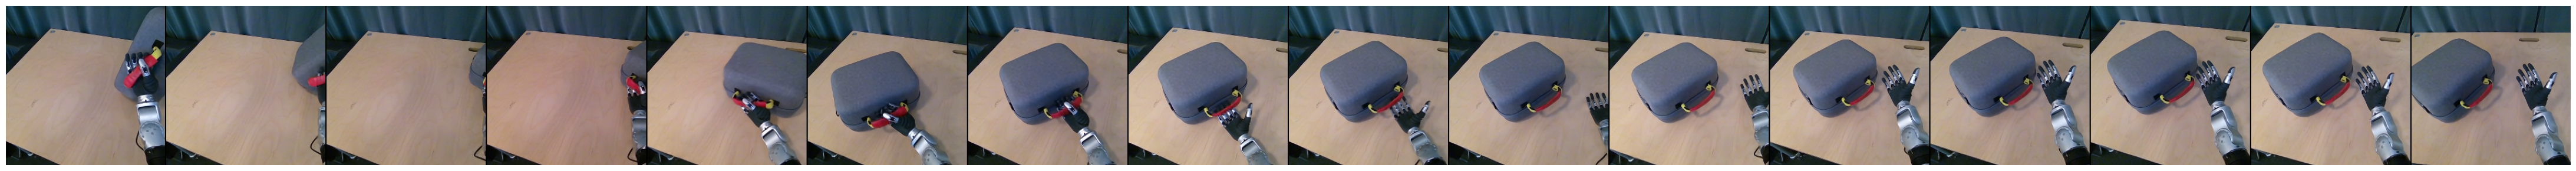

In [16]:
from torch.nn.functional import interpolate
imgs = sample["image"] 
imgs = interpolate(imgs, resolution).to(device=device)[None] # resize to tokenizer resolution

with torch.no_grad():
    with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
        latents = tokenizer.encode(imgs)
        imgs_recon = tokenizer.decode(latents)

from mediapy import show_video
def plotVideo(video):
    imgs = video.cpu().permute(0,2,3,1).to(torch.float32).numpy()*255
    imgs = imgs.astype('uint8')
    mediapy.show_video(imgs, fps=10)

plotVideo(imgs_recon[0])
plotVideo(imgs[0])
plotSnapshots(imgs_recon[0].to(torch.float32), n_frames=16, save_path="results/1.png")